<img src="https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# DBSCAN

**Density-Based Spatial Clustering of Applications with Noise (DBSCAN)** is one of the most influential and widely used clustering algorithms in unsupervised machine learning. Unlike partitioning algorithms such as k-means, DBSCAN groups data points based on their local density, allowing it to discover clusters of arbitrary shape while simultaneously identifying outliers as noise. Because many real-world datasets contain irregularly shaped clusters and noisy observations, DBSCAN has become a popular choice in fields such as data mining, computer vision, geospatial analysis, bioinformatics, and anomaly detection.

The key idea behind DBSCAN is that clusters correspond to regions of high point density separated by regions of lower density. Using two hyperparameters, $Eps$ (the neighborhood radius) and $MinPts$ (the minimum number of neighboring points required to form a dense region), the algorithm classifies data points as **core points**, **border points**, or **noise points**. Clusters are then formed by expanding connected dense regions from core points. This density-based approach enables DBSCAN to detect clusters with complex, non-convex shapes without requiring the number of clusters to be specified in advance.

Despite its many advantages, DBSCAN also has important limitations. Its performance depends heavily on selecting appropriate values for $Eps$ and $MinPts$, and finding suitable hyperparameters is often challenging in practice, particularly for datasets containing clusters with varying densities or high-dimensional features. Understanding these strengths and weaknesses is essential for determining when DBSCAN is an appropriate choice and how its results should be interpreted.

In this notebook, we explore the theoretical foundations of DBSCAN, discuss its advantages and limitations, and examine practical techniques for selecting its hyperparameters. To develop a deeper understanding of how the algorithm operates, we also implement DBSCAN from scratch, illustrating each step of the clustering process without relying on existing library implementations. Given its widespread use and importance in modern data analysis, developing a solid understanding of DBSCAN is an essential part of learning clustering and unsupervised machine learning.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
from src.utils.libimports.dbscan import *
from src.utils.helpers.dbscan import *
from src.utils.plotting.dbscan import *
from src.utils.data.files import *

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
demo_date_dbscan, _     = download_dataset("tabular/clustering/clustering-dbscan-example-data.csv")
demo_data_densities1, _ = download_dataset("tabular/clustering/clustering-data-different-densities1.csv")
demo_data_densities2, _ = download_dataset("tabular/clustering/clustering-data-different-densities2.csv")

File 'data/datasets/tabular/clustering/clustering-dbscan-example-data.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-different-densities1.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-different-densities2.csv' already exists (use 'overwrite=True' to overwrite it).


---

## Overview


### Motivation

To get a first intuition about what sets DBSCAN apart from many other cluster algorithms, it is useful to compare its behavior with another common cluster algorithm. To this end, let's first load the example dataset we will be using throughout the notebook. The code cell below loads the data from a file and uses the provided auxiliary method `plot_labels()` to plot all data points &mdash; without any cluster labels, this method simply plots the raw data.

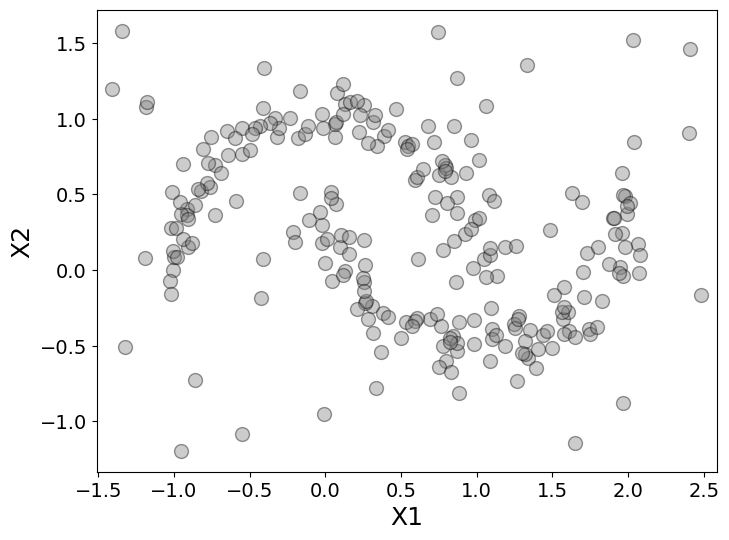

In [3]:
X = pd.read_csv(demo_date_dbscan).to_numpy()

plot_labels(X)

Without any ground-truth labels, it is always somewhat subjective when it comes to the question of what constitutes meaningful clusters. However, in the plot above, it seems not unreasonable to see $2$ crescent-shape clusters as well as some data points that arguably do not belong to any of these $2$ clusters. With this intuition in mind, let's see what the K-Means cluster algorithm with $K=2$ (i.e., we want $2$ clusters) returns in terms of a set of clusters; we use the [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) class of the [scikit-learn](https://scikit-learn.org/) library for that, and again use the `plot_labels()` method to visualize the results.

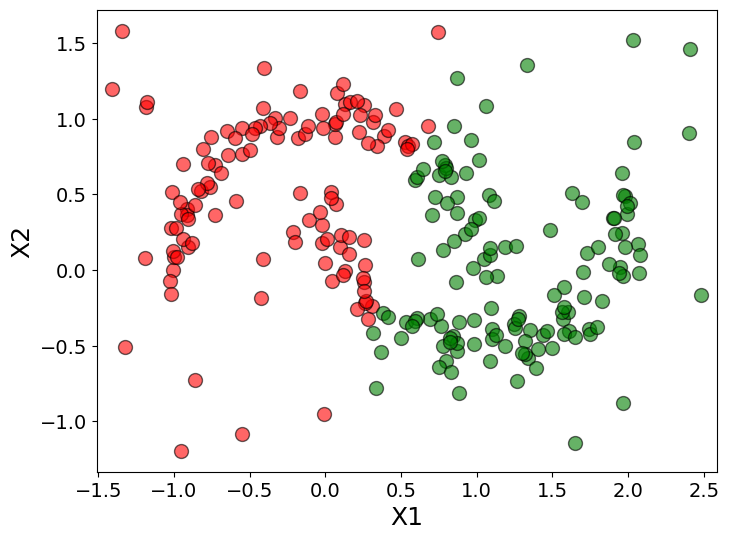

In [4]:
kmeans_clustering = KMeans(n_clusters=2).fit(X)

plot_labels(X, kmeans_clustering.labels_)

Clearly, this result does not match our intuition. For one, K-Means fails to capture the $2$ crescent-shaped clusters. This is because K-Means &mdash; given its definition which is beyond our scope here &mdash; favors "blob-like" / globular clusters. K-Means performs purely in the presence of "natural" clusters, i.e., clusters with more intricate shapes such as our $2$ crescents.

Moreover, the data points we considered do not belong to any clusters get, in fact, assigned to a cluster by K-Means. The K-Means cluster algorithm returns complete and exclusive clusterings, meaning that each data point gets assigned exactly one cluster. In other words, K-Means does not "ignore" any data points when finding good clusters. This makes K-Means also rather susceptible to outliers.

So let's compare it with DBSCAN using the [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) class of the [scikit-learn](https://scikit-learn.org/) library. Right now, we do not need to care how the algorithm works nor what the input arguments `eps` and `min_samples` mean; all this we will cover later in great detail. 

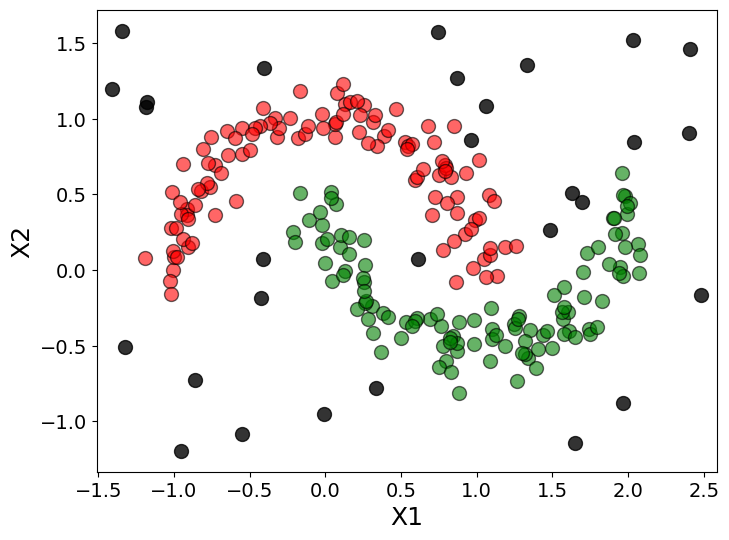

In [5]:
dbscan_clustering = DBSCAN(eps=0.2, min_samples=5).fit(X)

plot_labels(X, labels=dbscan_clustering.labels_)

This resulting set of clusters seems much preferred over then one provided K-Means. DBSCAN is both capable of capturing the natural, crescent-shaped clusters (red and blue data points), as well as ignoring the data points not belonging to any clusters (black data points). Summing up, this basic example highlights the strengths of DBSCAN compared to many other clustering algorithms such as K-Means, that generally favor blob-like clusters.

### Core Characteristics

Clustering algorithms can be categorized according to different characteristics. One of the most practical characteristics refers to the types of clusters and sets of clusters (i.e., clusterings) the algorithms are designed to discover. In more detail, DBSCAN returns clustering with of the following types:

* **Partitional & exclusive:** DBSCAN clusters are non-overlapping subsets; a data point cannot belong to more than one cluster.
* **Partial:** Not all data points may be assigned to any cluster. This is in contrast to complete clustering where each data point belongs to at least one cluster.
* **Density-based:** As it is in its name, DBSCAN implements the notion of a cluster by grouping data points that are tightly grouped together into the same cluster. To this end, DBSCAN measures the density of data points in their regions. By considering only local regions, DBSCAN is able to capture natural clusters.

Like all cluster algorithms, DBSCAN relies on computing the distances between data points. While DBSCAN is not constrained to any particular distance metric, in the following, we assume the use of the Euclidean Distance as the default metric. As such, we assume as input a dataset $D = \{\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_n \}$, with $\mathbf{x}_i \in \mathbb{R}^d$ &mdash; each data sample $\mathbf{x}_i$ is a point in the $d$-dimensional Euclidean space. This requires that categorical features need to be appropriately encoded as numerical features.

Lastly, compared to K-Means and many other cluster algorithms, we do not specify the number of clusters as an input argument of the DBSCAN algorithm. Instead, we specify the notion of density &mdash; full details later &mdash; and let the algorithm infer the number of meaningful clusters. We will see how specifying the "appropriate level density" is one of the main challenges when applying DBSCAN in practice.

### Main Concept: Density

In physical terms, density is a fundamental property of matter that measures how tightly packed the particles within a substance are, defined formally as the amount of mass $m$ contained within a specific unit of volume $V$, i.e., $m/V$. In the context of DBSCAN, the mass $m$ refers to the number of data points, and $V$ refers to a volume in the $d$-dimensional Euclidean space. In simple terms, a collection of data points with similar feature values &mdash; and thus close together in the feature space &mdash; describes a dense region.

DBSCAN therefore introduces two notations to specify density &mdash; we adhere to the notation used in the original [DBSCAN paper](https://file.biolab.si/papers/1996-DBSCAN-KDD.pdf):

* $Eps$ (epsilon) defines the maximum distance between two data points for them to be considered neighbors. It determines the size of the neighborhood around each point and plays a key role in identifying dense regions. The $Eps$-neighborhood of a data point $\mathbf{x}$, denoted by $N_{Eps}(\mathbf{x})$, is the set of data points with a distance to $\mathbf{x}$ smaller than $Eps$, i.e., $N_{Eps}(\mathbf{x}) = \{\mathbf{x}_i\in D\mid dist(\mathbf{x}, \mathbf{x}_i) \leq Eps \} $, where $dist(\cdot,\cdot)$ is some distance metric (e.g., the Euclidean distance). This notion of $Eps$-neighborhood reflects the volume $V$ in the traditional definition of density.

* $MinPts$ (minimum points) specifies the minimum number of data points required within the $Eps$-neighborhood for a point to be considered "dense enough to indicate a cluster" &mdash; we will specify this in more detail when covering the full algorithm. Notice that the definition of $N_{Eps}(\mathbf{x})$ contains the data point $\mathbf{x}$ itself. Thus, when specifying a value for $MinPts$, we need to keep in mind that we also have to take the presence of $\mathbf{x}$ into account. Note that the [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) class of the [scikit-learn](https://scikit-learn.org/) library uses the argument `min_samples` to specify $MinPts$.

**Side note:** Since the $Eps$-neighborhood of a point always includes the point itself, setting $MinPts = 1$ means that every point can form a cluster, even if it has no neighboring points within the Eps distance. Thus, isolated points become single-point clusters, ensuring that each point belongs to at least its own cluster. We can show this using our example dataset. In fact, we set $Eps$ to a very small value so that each data point's neighborhood does indeed only contain the data point itself.

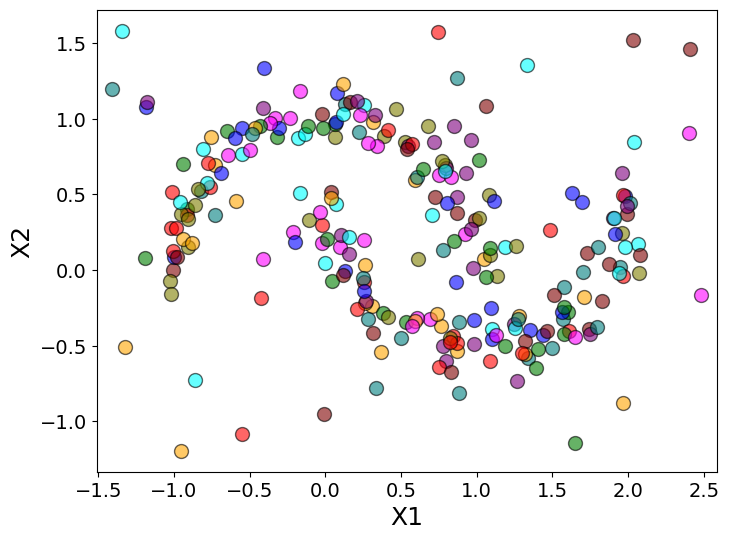

In [6]:
dbscan_clustering = DBSCAN(eps=0.00001, min_samples=1).fit(X)

plot_labels(X, labels=dbscan_clustering.labels_)

**Important:** The method `plot_labels()` only supports $10$ different colors to mark clusters. Thus, if there are more than $10$ clusters, the method will use the same colors for different colors. This is why many data points in the plot above have the same color, although each data point represents its own cluster. 

$Eps$ and $MinPts$ are the main input arguments of the DBSCAN algorithm. The only other common argument is the choice of the distance metric. In this notebook, we limit ourselves to the Euclidean Distance, so we ignore this input argument. However, keep in mind that DBSCAN works for any valid distance function between two points.

---

## The DBSCAN Algorithm

DBSCAN is naturally specified as an explicit step-by-step algorithm rather than through an optimization objective. Its behavior is defined procedurally: starting from an unvisited point, it determines whether the point is a core point based on its local neighborhood, expands clusters by recursively traversing density-reachable points, and labels any remaining points as noise. The resulting clustering is therefore the outcome of this deterministic sequence of operations, not the solution to a global optimization problem. This stands in contrast to many other clustering methods, such as K-Means or Gaussian mixture models, which are defined by optimizing an explicit objective function (e.g., minimizing within-cluster variance or maximizing data likelihood). Emphasizing DBSCAN's algorithmic definition is important because it highlights that its correctness and properties must be analyzed in terms of the procedural rules governing cluster expansion, rather than through the optimality conditions of an underlying objective function.

Let's now see how the algorithm works in detail.

### Types of Data Points

The DBSCAN algorithm distinguishes $3$ types of data points; when running the algorithm each data points is assigned one of those types:

* **Core points.** A data point $\mathbf{x}$ is a core point if its $Eps$-neighborhood contains at least $MinPts$ data points, i.e., if $|N_{Eps}(\mathbf{x})| \geq MinPts$ (again, remember that the neighborhood contains $\mathbf{x}$ itself). Core points form the interior of clusters.

* **Border points.** A data point $\mathbf{x}$ is a border point if $\mathbf{x}$ is in the neighborhood of at least one core point but is not a core point itself. Border points (kind of) form the exterior of clusters.

* **Noise points.** A data point $\mathbf{x}$ is a noise point if $\mathbf{x}$ is neither a core point nor a border point.

Both core and border points form the final clusters returned as the result from DBSCAN. This includes that the final result no longer distinguishes between core and border points; this distinction is only part of the algorithm.

At the beginning of the algorithm, all data points are considered unexplored or unknown, meaning that no data point is assigned any of those three point types. At some point during the algorithm, each data point will be explored to see if it is a core, border, or noise point. Since we implement the DBSCAN algorithm from scratch, let's define those $3+1$ point types (core/border/noise + unknown) as constants for later use.

In [7]:
POINT_TYPE_UKNOWN = 0
POINT_TYPE_CORE   = 1
POINT_TYPE_BORDER = 2
POINT_TYPE_NOISE  = 3

The algorithm eventually stops once all data points have been explored and assigned to a point type. The assignment of data points to their types is done in two steps: the **discovery step** and the **exploration step**, which we will discuss next. 

During the algorithm, data points get assigned to clusters in terms of labels that represent cluster IDs, typically starting from $0$ and then increasing incrementally by one for the next cluster &mdash; and we implement it the same way. However, we need $2$ additional cluster labels as part of the algorithm: (a) to represent that a data point's cluster assignment is not yet known, and (b) that a data point is labeled as a noise point. Let's therefore define also the following to additional constants.

In [8]:
CLUSTER_UNKNOWN = -2
CLUSTER_NOISE   = -1

To some extent, the values for both constants are arbitrary. It is mainly important not to use positive integers since positive integers are used to mark valid clusters. Using $-1$ to label noise points matches the approach of the DBSCAN implementation of [scikit-learn](https://scikit-learn.org/) library. The label for an unknown cluster assignment can be any negative integer except $-1$.

### Discovery Step

By definition, each cluster must contain at least $1$ core point, i.e., at least for $1$ data point its neighborhood must be "dense enough" with respect to $Eps$ and $MinPts$. Thus, to find a new cluster, we need to find one of its core points. The DBSCAN algorithm does this by randomly sampling all unexplored/unknown data points to see if they are core points. If we assume that we sample an unknown data point $\mathbf{x}$, there are two outcomes:

* $\mathbf{x}$ is *not* a core point $\Rightarrow$ mark $\mathbf{x}$ is a noise point (this might change later!)
* $\mathbf{x}$ is a core point $\Rightarrow$ start exploration step with $\mathbf{x}$ as the seed point (see below)

We already know that checking if a data point is a core point means checking if its $Eps$-neighborhood contains at least $MinPts$ data points. To implement this, let's first define a method that computes the $Eps$-neighborhood for a given data point; see the method `get_neighbors()` in the code cell below. This method uses the `euclidean_distances()` method of the [scikit-learn](https://scikit-learn.org/) library to compute all pairwise distances between the data point in all other points in the dataset (including the point itself). The method then returns the indices of data points with a distance less or equal to $Eps$.

In [9]:
def get_neighbors(X, x, eps):
    # Compute the Euclidean distance between x and all data points
    distances = euclidean_distances(X, x.reshape(1,-1)).squeeze()
    # Return the indices of the data points that a closer than eps to x
    return np.where(distances <= eps)[0]

To test the method, let's consider the data point in `X` at index $100$, which is a data point in the lower crescent-shaped cluster, and $Eps = 0.2$.

In [10]:
x_idx, eps, min_samples = 100, 0.2, 5

neighbors = get_neighbors(X, X[x_idx], eps)

print(f"Neighborhood for data point {x_idx} (eps={eps}): {neighbors}")

Neighborhood for data point 100 (eps=0.2): [  6  16  23  25  49  61  79 100 182 186]


As the result shows, the $Eps$-neighborhood contains $10$ data points including the one at index $100$ itself. Thus testing if `x` is a core point or not simply means comparing `len(neighbors)` with the given value for $MinPts$. Then, depending on the result of this comparison, we either mark `x` as a noise point or start the exploration step with `x` as the see point. We implement this comparison when implementing the full algorithm later. Let's first cover the exploration step.

### Exploration Step

Once we have discovered a core point, we know that we have found a cluster. However, we do not know how large the cluster might be. While we could check all data points if they are core points during the discovery step, we would lose the information if two or more core points belong to the same cluster or not. To preserve this structural information about clusters, DBSCAN implements the exploration step.

The exploration step starts by initializing a set set $S$ with the core point found during the discovery step. Then, assuming we are currently exploring cluster $i$, for each data point $\mathbf{x}$ in $S$, the algorithm performs the following process:

* Label $\mathbf{x}$ as a core point and assign $\mathbf{x}$ to cluster $i$

* Get the $Eps$-neighborhood $N_{Eps}(\mathbf{x})$ for data point $\mathbf{x}$.

* For each neighbor $\mathbf{x}_n$ do

    * If $\mathbf{x}_n$ is *not* a core point (i.e., $|N_{Eps}(\mathbf{x}_n)| < MinPts$) $\Rightarrow$ label $\mathbf{x}_n$ as a border point and assign $\mathbf{x}_n$ to cluster $i$

    * If $\mathbf{x}_n$ is a core point (i.e., $|N_{Eps}(\mathbf{x}_n)| \geq MinPts$) and has not been explored yet $\Rightarrow$ add $\mathbf{x}_n$ to set $S$ (note that $\mathbf{x}_n$ will be assigned to cluster $i$ when the algorithm explores all points in $S$).

This process continues until set $S$ is empty, which means that we have explored all data points that belong to that cluster with respect to $Eps$ and $MinPts$. Notice that $S$ grows every time we find a new core point that belongs to the same current cluster and we add it to $S$. The method `explore()` in the code cell below provides a 1:1 implementation for the iterative process we have just described.

In [11]:
def explore(X, core_point_idx, eps, min_samples, cluster_id, labels, types):
    S = set([core_point_idx])

    while len(S) != 0:
        # Get the next index from S and remove from S
        c = S.pop()

        # Assigne type and cluster to data point
        labels[c] = cluster_id
        types[c]  = POINT_TYPE_CORE

        # Get Eps-neighborhood for current core point
        neighbors = get_neighbors(X, X[c], eps)

        for n in neighbors:
            # Get Eps-neighborhood of current neighbor 
            neighbors_of_neighbor = get_neighbors(X, X[n], eps)

            # Check if neighbor is a border or core point
            if len(neighbors_of_neighbor) < min_samples:
                types[n] = POINT_TYPE_BORDER   
                labels[n] = cluster_id
            else:
                if types[n] == POINT_TYPE_UKNOWN:
                    S.add(n)

Apart from the dataset, the initial core point (represented by its index in the dataset), as well as the values for $Eps$ and $MinPts$ (we use the term `min_samples` to mimic the naming convention of [scikit-learn](https://scikit-learn.org/)), the method `explore()` also requires the following input arguments:

* `cluster_id`: The unique ID of the cluster to which we assign each core and border point identified during the exploration step. Although, the exact values are not important, we assume that the first found cluster starts with ID $0$ and the ID is incremented by $1$ for each newly found cluster &mdash; again, this is to be in line with the [scikit-learn](https://scikit-learn.org/) implementation of DBSCAN.

* `labels`: The list of current cluster IDs for all data points, which gets updated for the core and border points found during the exploration step.

* `types`: The list of current point types for all data points, which gets updated for the core and border points found during the exploration step.

The code cell below shows an example application of the `explore()` method. We assume that the data point at index $100$ is the very first core point we found. This means that we use a cluster ID of $0$ and initialize the list of all point types as cluster labels with the default values representing "unknown".

In [12]:
cluster_id = 0
labels     = [CLUSTER_UNKNOWN] * X.shape[0]
types      = [POINT_TYPE_UKNOWN] * X.shape[0]

explore(X, x_idx, eps, min_samples, cluster_id, labels, types)

To look at the cluster we have found, we can again use the method `plot_labels()`. 

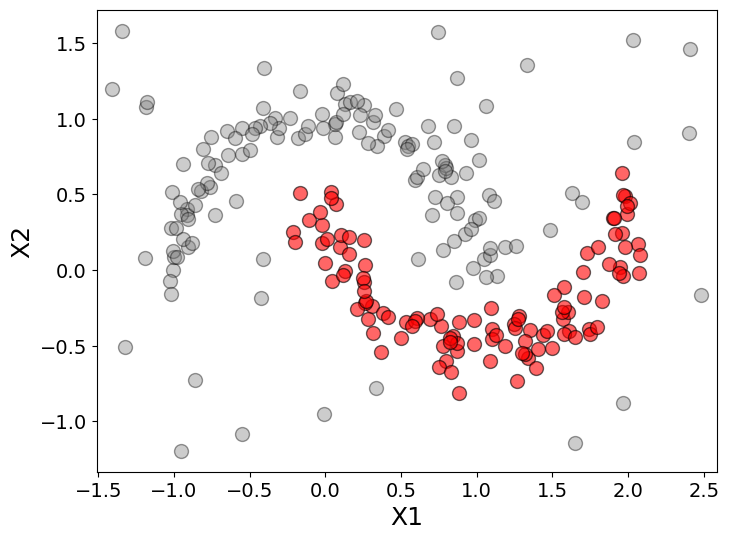

In [13]:
plot_labels(X, labels=labels)

Recall that the cluster labels (i.e., the actual output of the algorithm) do not distinguish between core and border points. However, for a better understanding of the DBSCAN algorithm, it is also useful to look at the individual point types. To this end, we also provide the auxiliary method `plot_types()` which shows the current point type for each data point. In the result plot, core points are blue, border points are cyan, and noise points are black; data points with an unknown type are shown in gray.

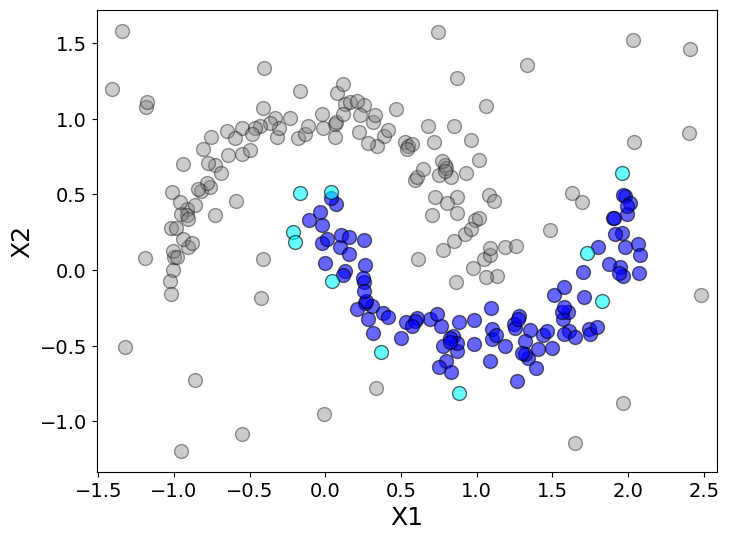

In [14]:
plot_types(X, types=types)

**Side note:** This example clearly shows that clusters are not necessarily completely surrounded by border points. In fact, depending on the dataset and the choice of $Eps$ and $MinPts$, a cluster may consist of only core points.

The method `explore()` returns the final result of the exploration step, and the methods `plot_labels()` and `plot_types()` allow to visualize that result, it is also very illustrative to capture and visualize all the intermediate steps during the exploration. We therefore provide the auxiliary method `explore_history()` which keeps track of all changes to the list of labels and list of types; otherwise, its code is exactly the same as for the `explore()` method shown above.

In [15]:
labels, label_history = [CLUSTER_UNKNOWN] * X.shape[0], []
types, type_history   = [POINT_TYPE_UKNOWN] * X.shape[0], []

explore_history(X, x_idx, eps, min_samples, cluster_id, labels, types, label_history, type_history)

Now that we have the history of changes for the labels and the types, we can visualize these histories using animations. In the case of the cluster labels, we provide the auxiliary method `plot_label_history()`; just run the code cell below to create the animation, but keep in mind that this might take a couple of seconds. By changing the value for `interval`, you can also speed up or slow down the animation.

In [16]:
plot_label_history(X, label_history=label_history, interval=100)

Similarly, we provide the method `plot_type_history()` to create an animation showing how data points get assigned to their respective types during the exploration step; again, running the code cell below might take a few seconds.

In [17]:
plot_type_history(X, type_history=type_history, interval=100)

Once a cluster has been fully explored &mdash; because set $S$ is empty since no new data point that was identified as a core point of the same cluster has been added, the exploration step is done, and the algorithm switches back to the discovery step.

### Full Algorithm

The full DBSCAN algorithm is now simply combining the discovery and exploration step and alternating between them until all data points have been explored. The method `dbscan()` in the code cell below implements the algorithm. Notice that the discovery step is represented by checking if the $Eps$-neighborhood of the current data point is large enough (i.e., larger than $MinPts$ / `min_samples`). If not, the current data point is a noise point, at least for the time being; otherwise the data point is a core point and the call the `explore()` method to find the whole cluster.

In [18]:
def dbscan(X, eps=0.5, min_samples=5):
    # Initialize
    labels = [CLUSTER_UNKNOWN] * X.shape[0]
    types  = [POINT_TYPE_UKNOWN] * X.shape[0]

    cluster_id =-1

    for idx, x in enumerate(X):
        
        # Check if sample has already been labeled; if Yes, nothing to do
        if types[idx] != POINT_TYPE_UKNOWN:
            continue

        # Get all neighbors of x (within minimum distance eps)
        neighbors = get_neighbors(X, x, eps)

        # If the number of neighbors is to small, label x as noise
        if len(neighbors) < min_samples:
            labels[idx] = -1
            types[idx]  = POINT_TYPE_NOISE
            continue

        # If we reach this part, we found a new core point x!
        cluster_id = cluster_id + 1

        # Perform exploration step for newly found core point
        explore(X, idx, eps, min_samples, cluster_id, labels, types)

    return labels, types

The method `dbscan()` returns both the list of cluster labels and the list of point types. Practical implementation typically only returns the cluster labels as the distinction between core points and border points is an internal detail of the algorithm. However, for a better understanding of the algorithm, our method also returns all point types.

Let's perform DBSCAN clustering on our example dataset using our `dbscan()` method with the same values for `eps` and `min_samples` we used before. We can then use the `plot_labels()` method to visualize all the final clusters, and the `plot_types()` method to visualize the distribution of point types.

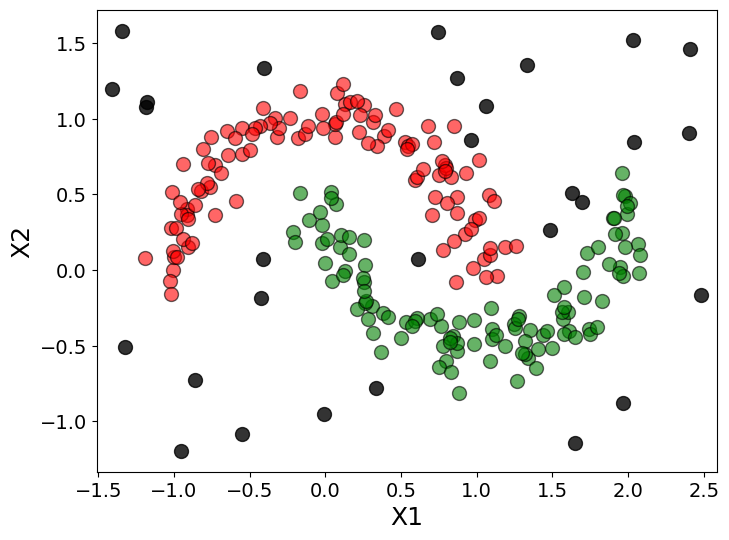

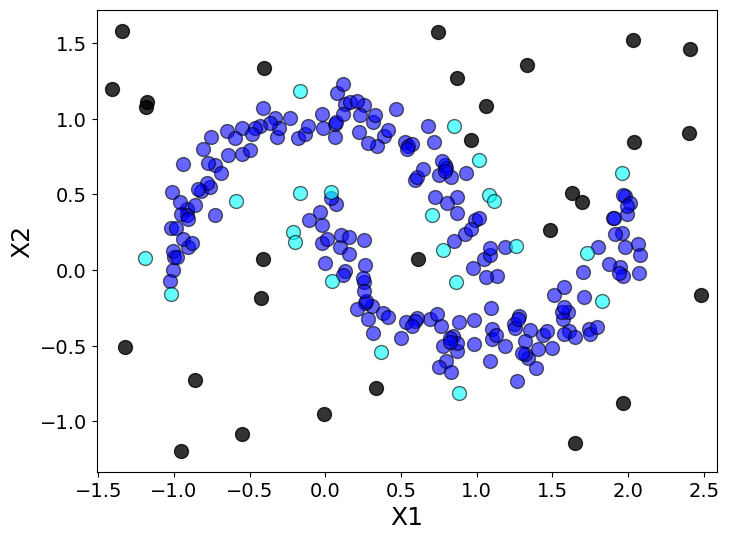

In [19]:
labels, types = dbscan(X, eps=eps, min_samples=min_samples)

plot_labels(X, labels=labels)
plot_types(X, types=types)

Of course, since we use the same values for `eps` and `min_samples` like at the very beginning for the motivating examples, the result in terms of the found cluster and noise points is the same. Like before, we would use the method `dbscan()` in practice as we are only interested in the final set of clusters. But again, to nicely visualize the process of the algorithm, we provide the method `dbscan_history()` that extends `dbscan()` by keeping track of all intermediate steps of the algorithm. As such, this method now also returns the history of all class labels and point types.

In [20]:
labels, types, label_history, type_history = dbscan_history(X, eps=eps, min_samples=min_samples)

Using our auxiliary methods, we can create animations showing the complete run of the algorithm. Let's first consider the history of the cluster labels for all data points in the dataset; this might take a few seconds.

In [21]:
plot_label_history(X, label_history=label_history, interval=100)

And we can do the same for the history of point types for all data points; again, this might take a few seconds.

In [22]:
plot_type_history(X, type_history=type_history, interval=100)

**Side note:** The two animations might give the wrong expression that the algorithm always first finds all the clusters and then all the noise points. However, during the discovery step, we go through all data points and it just so happens that in our example dataset, all noise points are at the end of the list. If noise points would be at the very beginning of the dataset, we would first see the few black data points appearing in the plot before we find our first core point. This order, however, has (almost!) no impact on the final result. 

### Discussion

Now that we know that the DBSCAN algorithm works, let's briefly discuss two questions: Does the algorithm always stop and converge? And does the algorithm always return the same clusters for the same dataset and values for $Eps$ and $MinPts$? While answering the first questions is rather straightforward, the second questions entails a subtle consideration but which essentially never matters in practice. 

#### Convergence

As it is quite easy to see from the arguably simple algorithm, DBSCAN is guaranteed to terminate because it operates on a **finite dataset** and marks each point as *visited* after processing it. Each point's neighborhood is examined at most once, and during cluster expansion, newly discovered points are only added to the exploration queue if they have not been visited before. Since there are only finitely many points, the algorithm cannot revisit points indefinitely or enter an infinite loop.

During the execution of DBSCAN, the label of a data point is essentially monotonic. A point that is initially found to have too few neighbors is temporarily labeled as **noise**. However, this label is provisional: if, during the expansion of a nearby cluster, the point is discovered to lie within the $Eps$-neighborhood of a core point, it is relabeled as a **border point** and assigned to that cluster. This is the only situation in which a point's label changes. Importantly, the reverse transition never occurs. Once a point has been assigned to a cluster as either a core or border point, it is never relabeled as noise or removed from the cluster. Consequently, point labels evolve in only one direction—from unassigned to noise or cluster member, and possibly from noise to border point. Because labels never oscillate between states, no fluctuations are possible, contributing to the algorithm's guaranteed termination.

#### Almost Deterministic Behavior

DBSCAN is almost deterministic: for a fixed distance metric, $Eps$, and `MinPts`, the set of **core points** (and the connected components they form) and the set of noise points are uniquely determined by the data. As a result, the identified clusters are generally independent of the order in which points are processed. The only ambiguity arises for **border points** that lie within the $Eps$-neighborhood of core points belonging to two different clusters. Such a border point is density-reachable from either cluster during the exploration step, so its final cluster assignment depends on which cluster reaches it first during the exploration process.

In most practical implementations, this ambiguity is resolved by assigning the border point to the **first** cluster that discovers it and leaving that assignment unchanged thereafter. In short, applying DBSCAN with the same values for $Eps$ and $MinPts$ on the same but differently shuffled dataset might yield (slightly) different sets of clusters. However, since border points do not participate in further cluster expansion, this choice does not affect the structure of the core-point clusters themselves. Consequently, while the assignment of a small number of border points may vary with the traversal order, the overall clustering remains stable and deterministic in almost all cases.

**Important:** This corner case only affects the final ownership of border points, not the existence or connectivity of the core-point clusters. This is why the ambiguity is considered minor: it may change the size of a cluster by one or a few border points, but it never changes which core points form a cluster or whether a cluster exists at all.

---

## Analysis & Behavior

One of the key advantages of DBSCAN is that, unlike algorithms such as (k)-means, it does not require the user to specify the number of clusters in advance. Instead, clusters emerge naturally as connected regions of sufficiently high point density, while isolated points are identified as noise. This makes DBSCAN particularly attractive when the number of clusters is unknown or when the data contains clusters of irregular shapes that cannot be well represented by centroid-based methods.

However, this flexibility comes at the cost of having to choose appropriate values for the neighborhood radius $Ep$ and the minimum number of neighbors $MinPts$. Selecting meaningful parameter values is often challenging in practice, as they depend on the scale, density, and distribution of the data. Small changes in $Eps$ or $MinPts$ can substantially alter the resulting clustering, causing clusters to split, merge, or disappear entirely. Consequently, DBSCAN is generally quite sensitive to its parameter settings, and identifying suitable values often requires domain knowledge, exploratory analysis, or heuristic techniques such as $k$-distance plots.

### Different Densities

A fundamental assumption of DBSCAN is that all clusters can be characterized by the same density threshold, as the algorithm uses a single global pair of parameters, $Eps$ and $MinPts$, for the entire dataset. Consequently, clusters with similar densities are typically identified successfully, whereas datasets containing clusters of substantially different densities pose a challenge. A parameter setting that correctly captures dense clusters may classify sparser clusters as noise, while increasing $Eps$ to recover sparse clusters may cause dense clusters to merge. As a result, the performance of DBSCAN can deteriorate considerably when the data contains clusters with heterogeneous densities.

To illustrate this, let's consider the following example dataset:

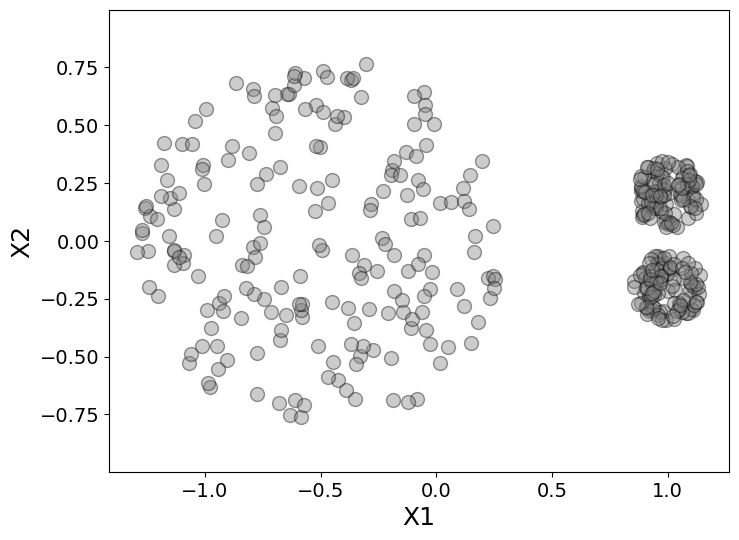

In [23]:
X_densities1 = pd.read_csv(demo_data_densities1).to_numpy()

plot_labels(X_densities1)

One could argue that this dataset contains $3$ circular clusters, but where the $2$ cluster on the right have a significantly higher density. Let's see which clusters DBSCAN will find with $Eps=0.1$ and $MinPts=10$ as the initial choice of parameter values.

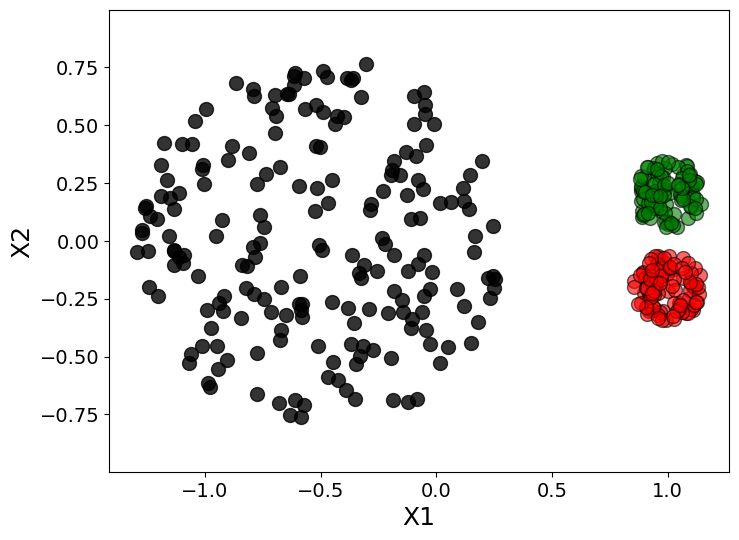

In [24]:
labels, types = dbscan(X_densities1, eps=0.1, min_samples=10)

plot_labels(X_densities1, labels=labels)

While the $2$ dense clusters have been captured nicely, the data points in the sparse region are all considered noise. If we want DBSCAN to capture this sparse region as a cluster, we would need to lower the required density, for example by increasing the value of $Eps$. Let's try $Eps = 0.25$ and run the DBSCAN algorithm again.

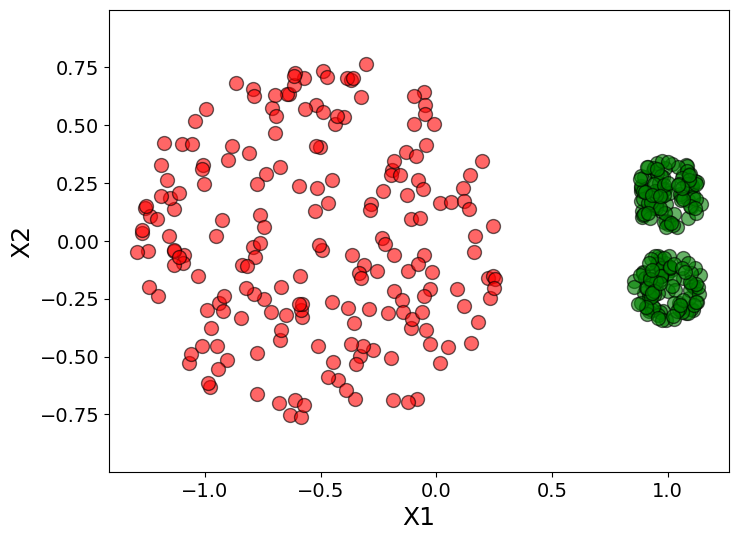

In [25]:
labels, types = dbscan(X_densities1, eps=0.25, min_samples=10)

plot_labels(X_densities1, labels=labels)

As the plot shows, the sparse region has now been captured as its own cluster. However, by increasing $Eps$, we lowered the minimum density so much that the $2$ dense regions on the right "collapsed" into a single cluster. Of course, apart from these two "extreme" cases, there are many other choices for $Eps$ and $MinPts$ one can try. To look at one more example, the code cell below runs DBSCAN with $Eps = 0.12$ and $MinPts = 3$.

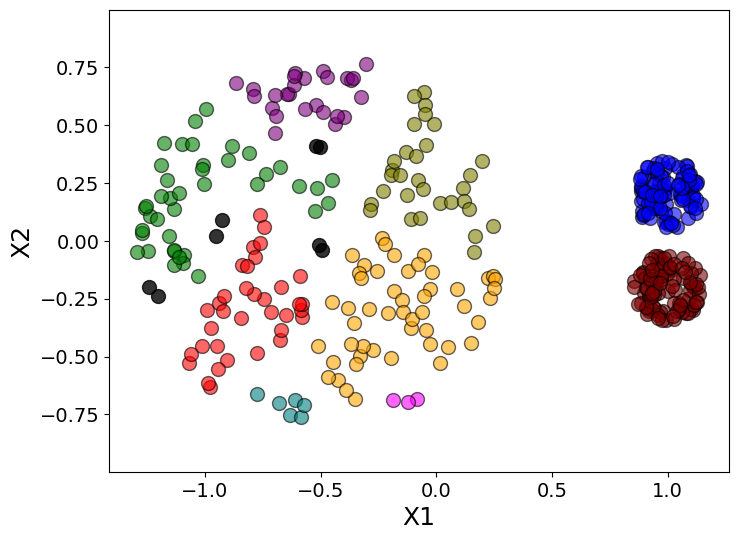

In [26]:
labels, types = dbscan(X_densities1, eps=0.12, min_samples=3)

plot_labels(X_densities1, labels=labels)

These parameter values capture the two dense regions as their own cluster, but not all data points in the sparse regions are noise points. Whether it is preferred to all data points in the sparse region being noise points is up for interpretation and will depend on the exact task and application. In any case, there is not choice of $Eps$ and $MinPts$ we could find where DBSCAN would return the $3$ clusters we might like to see from eye-balling the data distribution.

### Sensitivity to Parameters

Although the previous dataset already shows that even minor changes to the input parameters can change the result of DBSCAN, let's consider another dataset; see the code cell below.

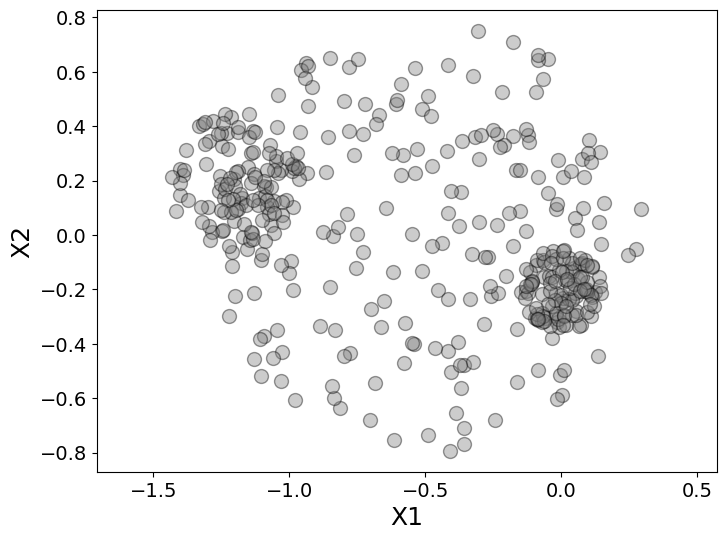

In [27]:
X_densities2 = pd.read_csv(demo_data_densities2).to_numpy()

plot_labels(X_densities2)

In this case, we do not have separate regions as before but a single one with arguable $2$ dense regions we might consider as cluster &mdash; since their density is much higher compared to the remaining data points. Let's first consider a "good" choice of values for $Eps$ and $MinPts$, meaning that the cluster return by DBSCAN more or less capture those $2$ dense(r) regions; we set $Eps=0.1$ and $MinPts =10$.

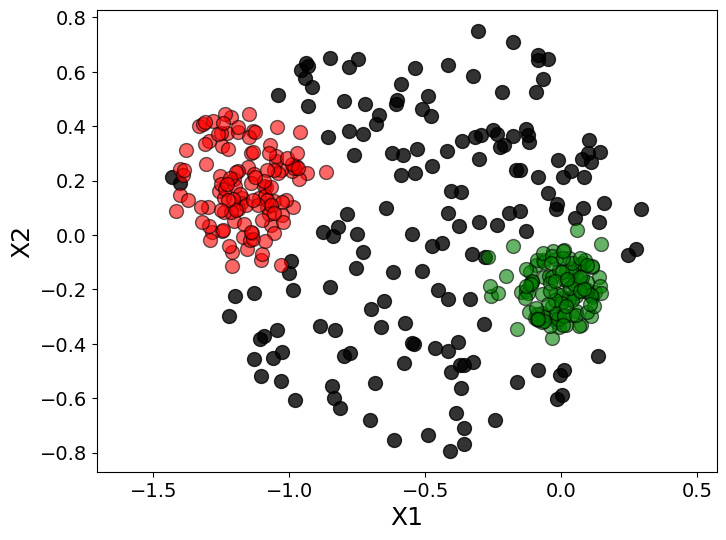

In [28]:
labels, types = dbscan(X_densities2, eps=0.1, min_samples=10)

plot_labels(X_densities2, labels=labels)

Just by looking at the plot, one could argue that the left cluster is missing some data points which have been labeled as noise points. On the other hand, some of the data points of the right cluster look a bit as if they should better be noise points. Let's try to address the latter by decreasing $Eps$ to $0.7$ and keep $MinPts = 10$. 

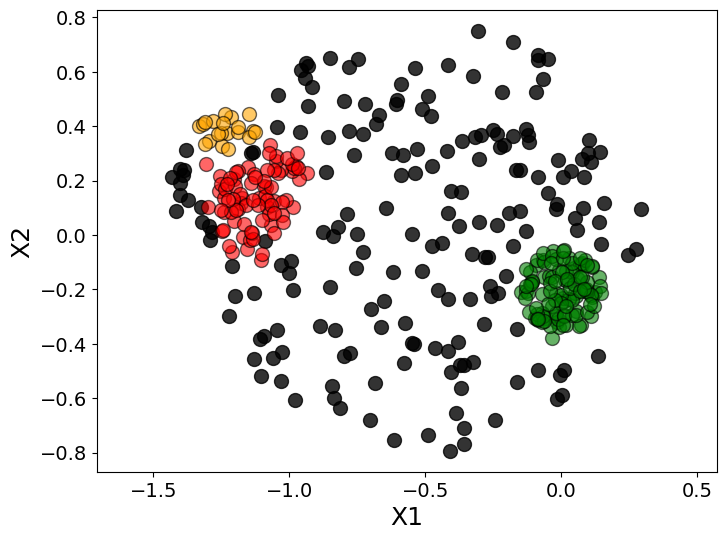

In [29]:
labels, types = dbscan(X_densities2, eps=0.07, min_samples=10)

plot_labels(X_densities2, labels=labels)

Now the right cluster is indeed limited to only the compact region of high density. However, the former left cluster is now generated. Not only are many data points that should arguably belong to the cluster now noise points, but the former single cluster is now split into $2$ clusters. If we want to capture the left cluster as a whole, we would therefore need to increase $Eps$. Let's therefore run DBSCAN with $Eps=0.12$ and, again, $MinPts=10$.

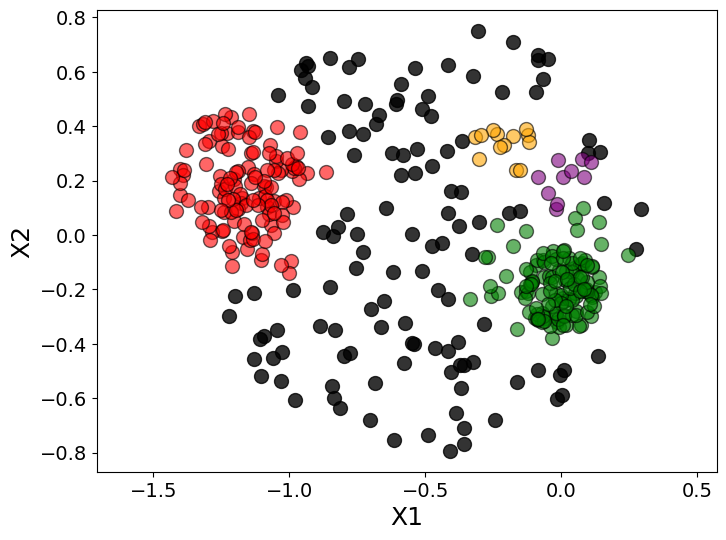

In [30]:
labels, types = dbscan(X_densities2, eps=0.12, min_samples=10)

plot_labels(X_densities2, labels=labels)

While we now capture the whole cluster on the left, we had to reduce the density so much that the final result contains an arguably spurious cluster &mdash; again, assuming that we would like to only get the $2$ dense(r) regions we identified when just looking at the raw data.

Summing up, selecting appropriate values for $Eps$ and $MinPts$ in DBSCAN is often one of the most challenging aspects of applying the algorithm. Unlike many clustering methods that require tuning only a single parameter, DBSCAN relies on two interdependent parameters that both influence the definition of density, but in different ways. While $Eps$ determines the size of the neighborhood around each point, $MinPts$ specifies the minimum number of neighboring points required to form a dense region. Because these parameters interact, adjusting one often changes the effect of the other, making it difficult to identify an optimal combination. Furthermore, determining meaningful initial values for $Eps$ and $MinPts$ is rarely straightforward in practice. The appropriate parameter ranges depend heavily on the characteristics of the dataset, such as its scale, dimensionality, and underlying density distribution.

### Finding "Good" Parameters

In all examples so far, we performed DBSCAN on a different dataset with some given values for $Eps$ and $MinPts$, without thinking about where those values came from. In practice, however, those values are not just given to us, but we need to find good or meaningful values for both parameters. Of course, in principle, we could just try different combinations of $Eps$ and $MinPts$ until we are happy with the results, but this raises two key questions:

* **How do we know that we are happy with the result?** All example datasets used in this notebook were 2-dimensional. This allowed for easily plotting the data to just "see" if the results are good (i.e., match our intuition). In practice, we often deal with higher dimensional datasets where straightforward plotting is no longer possible.

* **How can we find good initial values?** Trying different values for $Eps$ and $MinPts$ can be quite time and resource-intensive. It would be therefore useful to predetermine a meaningful range, particularly for $Eps$, to reduce the search space.

Let's see how we can address those questions in practice.

#### Core Challenges

In some applications, the choice of $Eps$ and $MinPts$ is determined directly by domain knowledge rather than by analyzing the data. For example, in geographic applications, $Eps$ may be chosen as a meaningful physical distance, such as 100 meters, to identify groups of nearby events or locations, while $MinPts$ specifies the minimum number of events required to constitute a hotspot. Similarly, in anomaly detection for sensor networks, $Eps$ may correspond to the maximum acceptable deviation between sensor readings, and $MinPts$ may reflect the minimum number of consistent measurements needed to regard a region as normal. In such settings, the parameters are selected to reflect application-specific requirements rather than to optimize the clustering itself, eliminating the need to search for the "best" values of $Eps$ and $MinPts$.

In general, however, selecting appropriate values for $Eps$ and $MinPts$ in DBSCAN is often one of the most challenging aspects of applying the algorithm. Unlike many clustering methods that require tuning only a single parameter, DBSCAN relies on two interdependent parameters that both influence the definition of density, but in different ways. While $Eps$ determines the size of the neighborhood around each point, $MinPts$ specifies the minimum number of neighboring points required to form a dense region. Because these parameters interact, adjusting one often changes the effect of the other, making it difficult to identify an optimal combination. Furthermore, determining meaningful initial values for $Eps$ and $MinPts$ is rarely straightforward in practice. The appropriate parameter ranges depend heavily on the characteristics of the dataset, such as its scale, dimensionality, and underlying density distribution.

#### Basic Hyperparameter Tuning

In many real-world clustering applications, we assume that the available data are unlabeled and that no ground truth exists against which the clustering results can be evaluated. Consequently, hyperparameter tuning for DBSCAN cannot rely on external validation measures (such accuracy for supervised classification tasks). Instead, we often need to rely internal clustering metrics, such as the **Sum of Squared Errors (SSE)** or the **Silhouette Score**, to assess clustering quality and guide the selection of suitable values for $Eps$ and $MinPts$.

However, this approach remains challenging in practice. Internal evaluation metrics provide only indirect estimates of clustering quality and may not always align with the true underlying structure of the data. For example, different metrics may favor different parameter settings, and some metrics are sensitive to noise, cluster shape, or varying cluster densities. Moreover, DBSCAN requires simultaneously tuning two interacting hyperparameters, $Eps$ and $MinPts$, which substantially increases the complexity of the search process compared to algorithms that require only a single parameter.

The challenges of using internal metrics such as SSE or Silhouette Score require a dedicated notebook and are not specific to DBSCAN but relate to cluster algorithms in general. We therefore omit a more detail discussed in this introductory notebook about DBSCAN.

#### k-Distance Plots

A $k$-distance plot is a heuristic tool commonly used to estimate a suitable value for the $Eps$ parameter in DBSCAN. To construct the plot, the distance from each data point to its $k$-th nearest neighbor is computed, where $k$ is typically chosen to match the $MinPts$ parameter. These distances are then sorted in ascending order and plotted. The resulting curve often exhibits a noticeable "knee" or "elbow," which marks the transition from points in dense regions to points in sparser regions or noise. 

Unfortunately, there is generally no automatic or universally optimal way to determine a suitable value for $MinPts$ in DBSCAN and, consequently, no definitive choice for the parameter $k$ used in a $k$-distance plot. The appropriate value depends on the characteristics of the dataset, including its dimensionality, noise level, and underlying density distribution. As a result, selecting $MinPts$ often relies on empirical guidelines rather than rigorous theoretical criteria. A commonly used rule of thumb is to set $MinPts$ to approximately twice the number of dimensions of the dataset (i.e., $MinPts \approx 2d$, where $d$ is the number of features), providing a reasonable starting point for subsequent parameter tuning.

To look at a $k$-distance plot, we provide the auxiliary method `plot_k_distance()`. In the code cell below, we apply this method to dataset `X` which refers to our initial example dataset containing the $2$ crescent shaped dense regions. Since this is a $2$-dimensional dataset, we set $k=2$ to follow the rule of thumb using a value twice the number of dimensions.

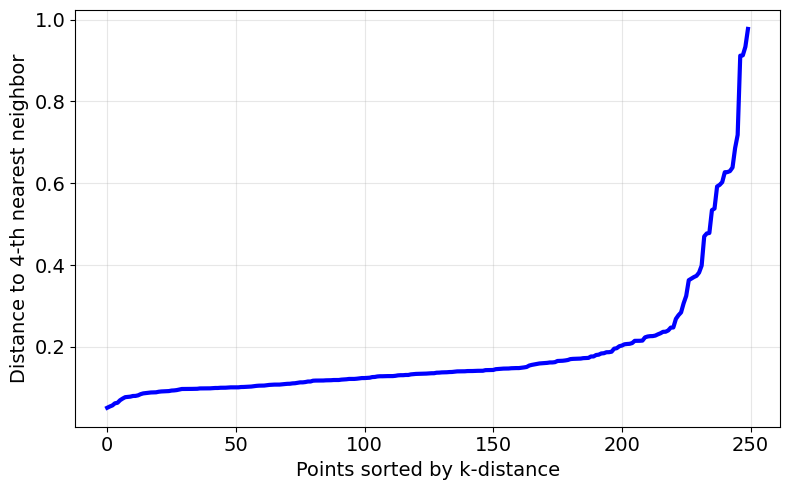

In [31]:
plot_k_distance(X, k=4)

A $k$-distance plot is interpreted by identifying the "knee" or "elbow" in the sorted k-nearest-neighbor distances. Points to the left of the knee generally belong to dense regions, where the $k$-th nearest-neighbor distances are relatively small and increase gradually. Beyond the knee, the distances increase much more rapidly, indicating points in sparse regions or potential outliers. A suitable value for $Eps$ is typically chosen near this transition point, as it provides a neighborhood radius that captures the dense clusters while excluding many noise points. For our example dataset, the knee is roughly for $Eps=0.22$ which closely matches the value of $Eps=0.2$ we used to get the $2$ clusters capturing the $2$ crescent-shaped dense regions. 

Selecting $Eps$ near this knee provides a reasonable starting point, as it captures the characteristic neighborhood radius of the dense clusters while excluding many outliers. However, identifying the knee is often subjective, and the method can become unreliable for datasets with varying cluster densities or high-dimensional data. 

---

## Summary

In this notebook, we introduced the **Density-Based Spatial Clustering of Applications with Noise (DBSCAN)** algorithm and explored the fundamental ideas behind density-based clustering. Unlike partitioning methods such as k-means, DBSCAN identifies clusters as dense regions of data separated by sparse areas, while naturally detecting noise and outliers. We examined the concepts of core, border, and noise points, as well as the roles of the two key hyperparameters, $Eps$ and $MinPts$, in determining the clustering result.

We also discussed the main strengths and limitations of DBSCAN. The algorithm is particularly effective at discovering clusters of arbitrary shape and does not require the number of clusters to be specified in advance. However, selecting appropriate values for $Eps$ and $MinPts$ can be challenging, especially for datasets with varying densities or high dimensionality. Techniques such as k-distance plots and internal clustering metrics can provide useful guidance, although they do not eliminate the need for careful parameter tuning.

To gain a deeper understanding of the algorithm, we implemented DBSCAN from scratch rather than relying solely on existing library implementations. This implementation illustrated the algorithm's core steps, including neighborhood queries, the identification of core points, and the iterative expansion of clusters. Building the algorithm from first principles provides valuable insight into how DBSCAN operates and why its behavior is strongly influenced by the chosen hyperparameters.

Overall, DBSCAN is one of the most widely used density-based clustering algorithms due to its ability to identify arbitrarily shaped clusters while handling noise effectively. Although it has limitations, its versatility and practical importance make it a fundamental algorithm in unsupervised machine learning. Understanding both its theoretical foundations and practical implementation is therefore an essential step toward mastering clustering techniques and applying them effectively to real-world datasets.